# Entregable Hito 1: Analisis exploratorio y preparación de datos
## PFC - Sistema Inteligente de Precios Dinámicos
**Autor:** Ricardo Fernández 
---

## 1. Introducción y Justificación de la Arquitectura

En la fase anterior (**Hito 0**), completamos con éxito el diseño y despliegue del pipeline de datos e infraestructura cloud. Este sistema capturó y procesó de forma híbrida tres tipos de fuentes de datos operacionales de distinta naturaleza física:
1.  **Amazon RDS (PostgreSQL)**: Contiene el inventario maestro estructurado y relacional de propiedades (`listings_master`).
2.  **MongoDB Atlas**: Almacena el corpus documental semiestructurado (JSON NoSQL) de reseñas históricas (`reviews_raw`).
3.  **Apache Kafka**: Captura y drena en tiempo real las interacciones dinámicas de navegación de los usuarios (clickstream).

Utilizando un clúster serverless de **AWS Glue con Apache Spark**, realizamos una federación de datos, cruzando las fuentes a través de la clave común `listing_id` y persistiendo los resultados en formato columnar optimizado **Apache Parquet** en nuestro bucket de **Amazon S3**.

Debido a la naturaleza de procesamiento distribuido del clúster de Spark, la salida se guardó fragmentada en aproximadamente 20 archivos Parquet individuales.

### Objetivos de esta Primera Mitad del Hito 1:
El propósito de este análisis consiste en bajar los datos consolidados de la nube, unificarlos localmente para agilizar los tiempos de respuesta y realizar un **Análisis Exploratorio de Datos (EDA)** exhaustivo que determine la calidad, patrones y relaciones de nuestro dataset antes de proceder al entrenamiento de modelos predictivos.


## 1. Importación de Librerías y Configuración de Visualizaciones

In [ ]:
import os
import glob
import json
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import boto3
from scipy import stats

# Configuración de estilos visuales para informes académicos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Cargar credenciales de AWS desde el archivo .env local
raiz_proyecto = Path.cwd().parent
env_path = raiz_proyecto / ".env"
load_dotenv(dotenv_path=env_path, override=True)

True

### 2. Ingesta Cloud Unificada a `/datasets/importado`

Para optimizar costes de cómputo en la nube y latencias de red en el cuaderno de Jupyter, utilizaremos la API de `boto3` para descargar secuencialmente los fragmentos distribuidos desde el Data Lake en S3. 

Posteriormente, utilizaremos las capacidades de lectura paralela de Pandas para unificar todos los fragmentos en memoria RAM y guardaremos un único archivo unificado consolidado bajo el formato binario optimizado Parquet en el directorio del proyecto `/datasets/importado/dataset_unificado.parquet`.

In [3]:
# Configurar rutas nativas usando Path (Evita problemas de slash '/' o '\' en Windows)
bucket_name = os.getenv("S3_BUCKET_NAME")
prefix_s3 = "curated/dataset_proptech_master/"
ruta_destino_local = raiz_proyecto / "datasets" / "importado"

# Asegurar la existencia física de la carpeta local de importación
os.makedirs(ruta_destino_local, exist_ok=True)

print("☁ Conectando con Amazon S3 con credenciales actualizadas...")
s3_res = boto3.resource('s3')
bucket = s3_res.Bucket(bucket_name)

count_descargas = 0
# Descargar iterativamente todos los fragmentos part-*.parquet del clúster
for obj in bucket.objects.filter(Prefix=prefix_s3):
    if obj.key.endswith('.parquet'):
        nombre_archivo = os.path.basename(obj.key)
        ruta_archivo_local = ruta_destino_local / nombre_archivo
        print(f"   📥 Descargando fragmento analítico: {nombre_archivo}")
        bucket.download_file(obj.key, str(ruta_archivo_local))
        count_descargas += 1

print(f"\n✔ Descargados con éxito {count_descargas} fragmentos Parquet.")
print("🔀 Unificando fragmentos locales en memoria RAM...")

# Pandas lee la carpeta entera heredando esquemas automáticamente
df_unificado = pd.read_parquet(str(ruta_destino_local))

print("🗑 Limpiando archivos fragmentados temporales de la carpeta...")
archivos_temporales = glob.glob(os.path.join(str(ruta_destino_local), "part-*"))
for f in archivos_temporales:
    os.remove(f)

# Persistencia del tablón de análisis unificado final
ruta_parquet_final = ruta_destino_local / "dataset_unificado.parquet"
df_unificado.to_parquet(str(ruta_parquet_final), index=False)

print("\n" + "="*70)
print("🌟 ¡PROCESO DE INGESTA AUTOMATIZADA FINALIZADO CORECTAMENTE!")
print(f"📂 Archivo unificado exportado a: {ruta_parquet_final.resolve()}")
print(f"📊 Dimensiones del dataset unificado: {df_unificado.shape[0]} filas y {df_unificado.shape[1]} columnas.")
print("="*70)

☁ Conectando con Amazon S3 con credenciales actualizadas...
   📥 Descargando fragmento analítico: part-00000-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00001-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00002-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00003-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00004-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00005-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00006-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00007-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.snappy.parquet
   📥 Descargando fragmento analítico: part-00008-4bb561d5-bc83-4bad-83e6-3df7d6412a28-c000.s

### 3. Inspección Inicial y Auditoría de Completitud de Datos

Una vez consolidado el tablón de datos multimodelo en nuestro entorno local, el primer paso fundamental del **Análisis Exploratorio de Datos (EDA)** consiste en realizar una inspección empírica de su estructura. 

Esta fase inicial tiene tres objetivos metodológicos clave:
1. **Validación del Esquema**: Verificar que las columnas clave del inventario de propiedades (`price`, `accommodates`, `room_type`) y las métricas cruzadas de MongoDB (`total_reviews_historicas`) y Kafka (`total_clicks_acumulados`) se hayan estructurado correctamente.
2. **Auditoría de Completitud**: Cuantificar la presencia de valores ausentes (`NaN` o nulos) introducidos durante la fase de extracción o causados por la naturaleza de los registros (por ejemplo, alojamientos sin clics acumulados o sin reseñas).
3. **Mapeo de Cardinalidad**: Evaluar el volumen de valores únicos por columna para identificar de forma temprana variables categóricas de alta dispersión.

In [4]:
# Definir la ruta física al archivo consolidado
raiz_proyecto = Path.cwd().parent
ruta_archivo_parquet = raiz_proyecto / "datasets" / "importado" / "dataset_unificado.parquet"

# Cargar el tablón unificado en memoria RAM
df = pd.read_parquet(str(ruta_archivo_parquet))

print(f"📊 Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("📌 PRIMEROS 5 REGISTROS DEL TABLÓN MAESTRO UNIFICADO:")
display(df.head(5))

print("\n🔍 TABLA DE AUDITORÍA DE CALIDAD DE DATOS Y COMPLETITUD:")
audit_df = pd.DataFrame({
    'Tipo de Columna (Dtype)': df.dtypes,
    'Registros Válidos': df.count(),
    'Valores Nulos (NaN)': df.isnull().sum(),
    'Porcentaje de Nulos (%)': (df.isnull().sum() / len(df) * 100).round(3),
    'Valores Únicos (Cardinalidad)': df.nunique()
})
display(audit_df)

📊 Dataset cargado con éxito. Dimensiones: 61106 filas y 88 columnas.

📌 PRIMEROS 5 REGISTROS DEL TABLÓN MAESTRO UNIFICADO:


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,region,total_reviews_historicas,total_clicks_acumulados
0,31562260,https://www.airbnb.com/rooms/31562260,20250930030808,2025-09-30,city scrape,Unos dias en Malaga AT Bonito y moderno loft 1ºD,"Modern, cozy and quiet apartments located a 5-...",The apartment is close to the attractions of t...,https://a0.muscache.com/pictures/7f10b9f9-6975...,235242238,...,A/MA/01347,t,3,3,0,0,3.07,Málaga,0,0
1,1257195478073374071,https://www.airbnb.com/rooms/1257195478073374071,20250914152907,2025-09-15,city scrape,Farmacia V,This modern apartment is part of a brand new r...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,438136382,...,NaN,f,407,407,0,0,0.41,Madrid,0,0
2,31301774,https://www.airbnb.com/rooms/31301774,20251214012024,2025-12-14,city scrape,2-bedroom apartment in the Old Town,Located just a few meters from Las Ramblas and...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,234256283,...,Spain - National registration number<br />ESFC...,t,22,22,0,0,0.48,Barcelona,0,0
3,898560962298545613,https://www.airbnb.com/rooms/898560962298545613,20251214012024,2025-12-14,city scrape,Unique Apt in the heart of historic Barcelona,One-of-a-kind retreat for 5 People in the hear...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,5543127,...,Barcelona - Regional registration number<br />...,t,14,14,0,0,2.33,Barcelona,0,0
4,39719010,https://www.airbnb.com/rooms/39719010,20250914152907,2025-09-15,previous scrape,Habitación privada,We're a couple who rent a small private room.,Quiet but central neighborhood. Supermarkets o...,https://a0.muscache.com/pictures/c97a4d15-70db...,4761745,...,NaN,f,1,0,1,0,0.01,Madrid,0,0



🔍 TABLA DE AUDITORÍA DE CALIDAD DE DATOS Y COMPLETITUD:


,Tipo de Columna (Dtype),Registros Válidos,Valores Nulos (NaN),Porcentaje de Nulos (%),Valores Únicos (Cardinalidad)
listing_id,str,61106,0,0.000,61106
listing_url,str,61106,0,0.000,61106
scrape_id,str,61106,0,0.000,4
last_scraped,str,61106,0,0.000,6
source,str,61106,0,0.000,2
...,...,...,...,...,...
calculated_host_listings_count_shared_rooms,int64,61106,0,0.000,13
reviews_per_month,float64,49147,11959,19.571,1128
region,str,61106,0,0.000,4
total_reviews_historicas,int64,61106,0,0.000,111


### 4. Perfilado Estadístico y Tendencias Centrales

Para comprender la distribución del mercado inmobiliario PropTech y el comportamiento de la demanda, es indispensable realizar un perfil descriptivo riguroso de las variables numéricas continuas y discretas. 

En esta sección calcularemos e interpretaremos las siguientes métricas estadísticas:
* **Media Aritmética**: Centro de gravedad de los datos (sensible a valores extremos).
* **Mediana ($Q_2$ o Percentil 50%)**: El valor central que divide la muestra exactamente a la mitad; métrica robusta e inmune a distorsiones por propiedades de súper-lujo.
* **Moda**: El valor con mayor frecuencia absoluta dentro de cada columna, indicando el estándar de mercado.
* **Desviación Estándar ($\sigma$)**: Medida de dispersión absoluta que cuantifica cuánto varían los datos respecto a su media.
* **Desglose de Percentiles (P10, P25, P75, P90)**: Mapeo de los cortes de la muestra para identificar la asimetría y concentración de las tarifas y el clickstream.

In [5]:
print("📊 INFORME DE ESTADÍSTICAS DESCRIPTIVAS COMPLETAS (Variables Numéricas):")

# 1. Obtener estadísticas descriptivas estándar y percentiles requeridos
desc_base = df.describe(percentiles=[.10, .25, .50, .75, .90]).T

# 2. Incorporar la Mediana de forma explícita
desc_base['mediana'] = df.median(numeric_only=True)

# 3. Calcular la Moda de manera iterativa para cada variable numérica
dict_modas = {}
for col_name in df.select_dtypes(include=[np.number]).columns:
    moda_res = df[col_name].mode()
    dict_modas[col_name] = moda_res[0] if not moda_res.empty else np.nan

desc_base['moda'] = pd.Series(dict_modas)

# 4. Seleccionar y ordenar las columnas para cumplir las directrices académicas
desc_final = desc_base[['mean', 'mediana', 'moda', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max']]
desc_final.columns = [
    'Media', 'Mediana', 'Moda', 'Desviación Estándar', 
    'Mínimo', 'Percentil 10', 'Percentil 25 (Q1)', 'Percentil 50 (Q2)', 
    'Percentil 75 (Q3)', 'Percentil 90', 'Máximo'
]

display(desc_final.round(2))

📊 INFORME DE ESTADÍSTICAS DESCRIPTIVAS COMPLETAS (Variables Numéricas):


,Media,Mediana,Moda,Desviación Estándar,Mínimo,Percentil 10,Percentil 25 (Q1),Percentil 50 (Q2),Percentil 75 (Q3),Percentil 90,Máximo
hosts_time_as_user_years,7.78,8.00,12.00,4.19,0.00,2.00,5.00,8.00,11.00,13.00,1.700000e+01
hosts_time_as_user_months,5.32,6.00,6.00,3.39,0.00,0.00,2.00,6.00,8.00,10.00,1.100000e+01
hosts_time_as_host_years,7.03,7.00,5.00,4.25,0.00,1.00,3.00,7.00,11.00,13.00,1.400000e+01
hosts_time_as_host_months,5.27,5.00,6.00,3.30,0.00,1.00,2.00,5.00,8.00,10.00,1.100000e+01
host_listings_count,66.04,7.00,1.00,157.15,1.00,1.00,2.00,7.00,43.00,209.00,2.874000e+03
host_total_listings_count,84.21,9.00,1.00,198.34,1.00,1.00,2.00,9.00,57.00,256.00,8.775000e+03
latitude,39.71,40.42,41.39,1.79,36.65,36.72,37.39,40.42,41.38,41.40,4.146000e+01
longitude,-2.37,-3.70,2.16,3.04,-6.01,-5.99,-4.42,-3.70,2.15,2.17,2.220000e+00
accommodates,3.49,3.00,2.00,2.11,1.00,1.00,2.00,3.00,4.00,6.00,1.600000e+01
bathrooms,1.35,1.00,1.00,0.76,0.00,1.00,1.00,1.00,2.00,2.00,1.900000e+01


### 5. Análisis Cuantitativo de Anomalías y Valores Atípicos (Outliers)

En las plataformas PropTech y en el análisis del comportamiento de navegación (clickstream), los valores extremos son muy recurrentes. Contamos con propiedades singulares con tarifas de súper-lujo o picos drásticos de clics causados por campañas de marketing o comportamientos de usuarios atípicos.

Para identificar cuantitativamente el volumen de anomalías de nuestro dataset sin sesgar la muestra, utilizaremos el método estadístico del **Rango Intercuartílico (IQR)**. 

Definiremos formalmente como valores atípicos aquellos registros que se sitúan fuera de las fronteras delimitadas por la expresión:

$$\text{Límites} = [Q_1 - 1.5 \cdot \text{IQR} \quad \text{a} \quad Q_3 + 1.5 \cdot \text{IQR}]$$

Donde $\text{IQR} = Q_3 - Q_1$ (la diferencia entre el percentil 75% y el 25%).

In [6]:
print("🚨 EVALUACIÓN CUANTITATIVA DE ANOMALÍAS USANDO EL MÉTODO IQR:\n")

# Variables críticas de análisis de negocio
variables_core = ['price', 'accommodates', 'total_reviews_historicas', 'total_clicks_acumulados']

for var in variables_core:
    if var in df.columns:
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)
        iqr = q3 - q1
        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr
        
        outliers = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
        pct_outliers = (len(outliers) / len(df)) * 100
        
        print(f"🔹 Variable Analizada: '{var}'")
        print(f"   - Rango operativo aceptado (Normal): [{limite_inf:.2f} a {limite_sup:.2f}]")
        print(f"   - Outliers detectados: {len(outliers)} de {len(df)} registros ({pct_outliers:.2f} %)")
        
        if var == 'price':
            print(f"   - Nota de negocio: Hay {len(df[df['price'] > 1000])} propiedades de súper-lujo con precio > $1000.")
        print("-" * 75)

🚨 EVALUACIÓN CUANTITATIVA DE ANOMALÍAS USANDO EL MÉTODO IQR:

🔹 Variable Analizada: 'price'
   - Rango operativo aceptado (Normal): [-54.50 a 293.50]
   - Outliers detectados: 2524 de 61106 registros (4.13 %)
   - Nota de negocio: Hay 403 propiedades de súper-lujo con precio > $1000.
---------------------------------------------------------------------------
🔹 Variable Analizada: 'accommodates'
   - Rango operativo aceptado (Normal): [-1.00 a 7.00]
   - Outliers detectados: 2774 de 61106 registros (4.54 %)
---------------------------------------------------------------------------
🔹 Variable Analizada: 'total_reviews_historicas'
   - Rango operativo aceptado (Normal): [0.00 a 0.00]
   - Outliers detectados: 127 de 61106 registros (0.21 %)
---------------------------------------------------------------------------
🔹 Variable Analizada: 'total_clicks_acumulados'
   - Rango operativo aceptado (Normal): [0.00 a 0.00]
   - Outliers detectados: 65 de 61106 registros (0.11 %)
----------------

### 6. Análisis Visual de Distribuciones, Dispersiones y Categorías

Para validar visualmente los patrones cuantitativos detectados, diseñaremos un cuadro de mandos con 4 componentes gráficos complementarios de alta calidad analítica. 

Esto nos permitirá evaluar la asimetría de la variable objetivo (Precio) y su comportamiento frente a las variables estructurales (tipo de habitación, huéspedes) y las señales dinámicas capturadas en tiempo real por Kafka.

C:\Users\Ric\AppData\Local\Temp\ipykernel_29896\1208052058.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=df[df['price'] < 400], ax=axes[0, 1], palette='Set2')


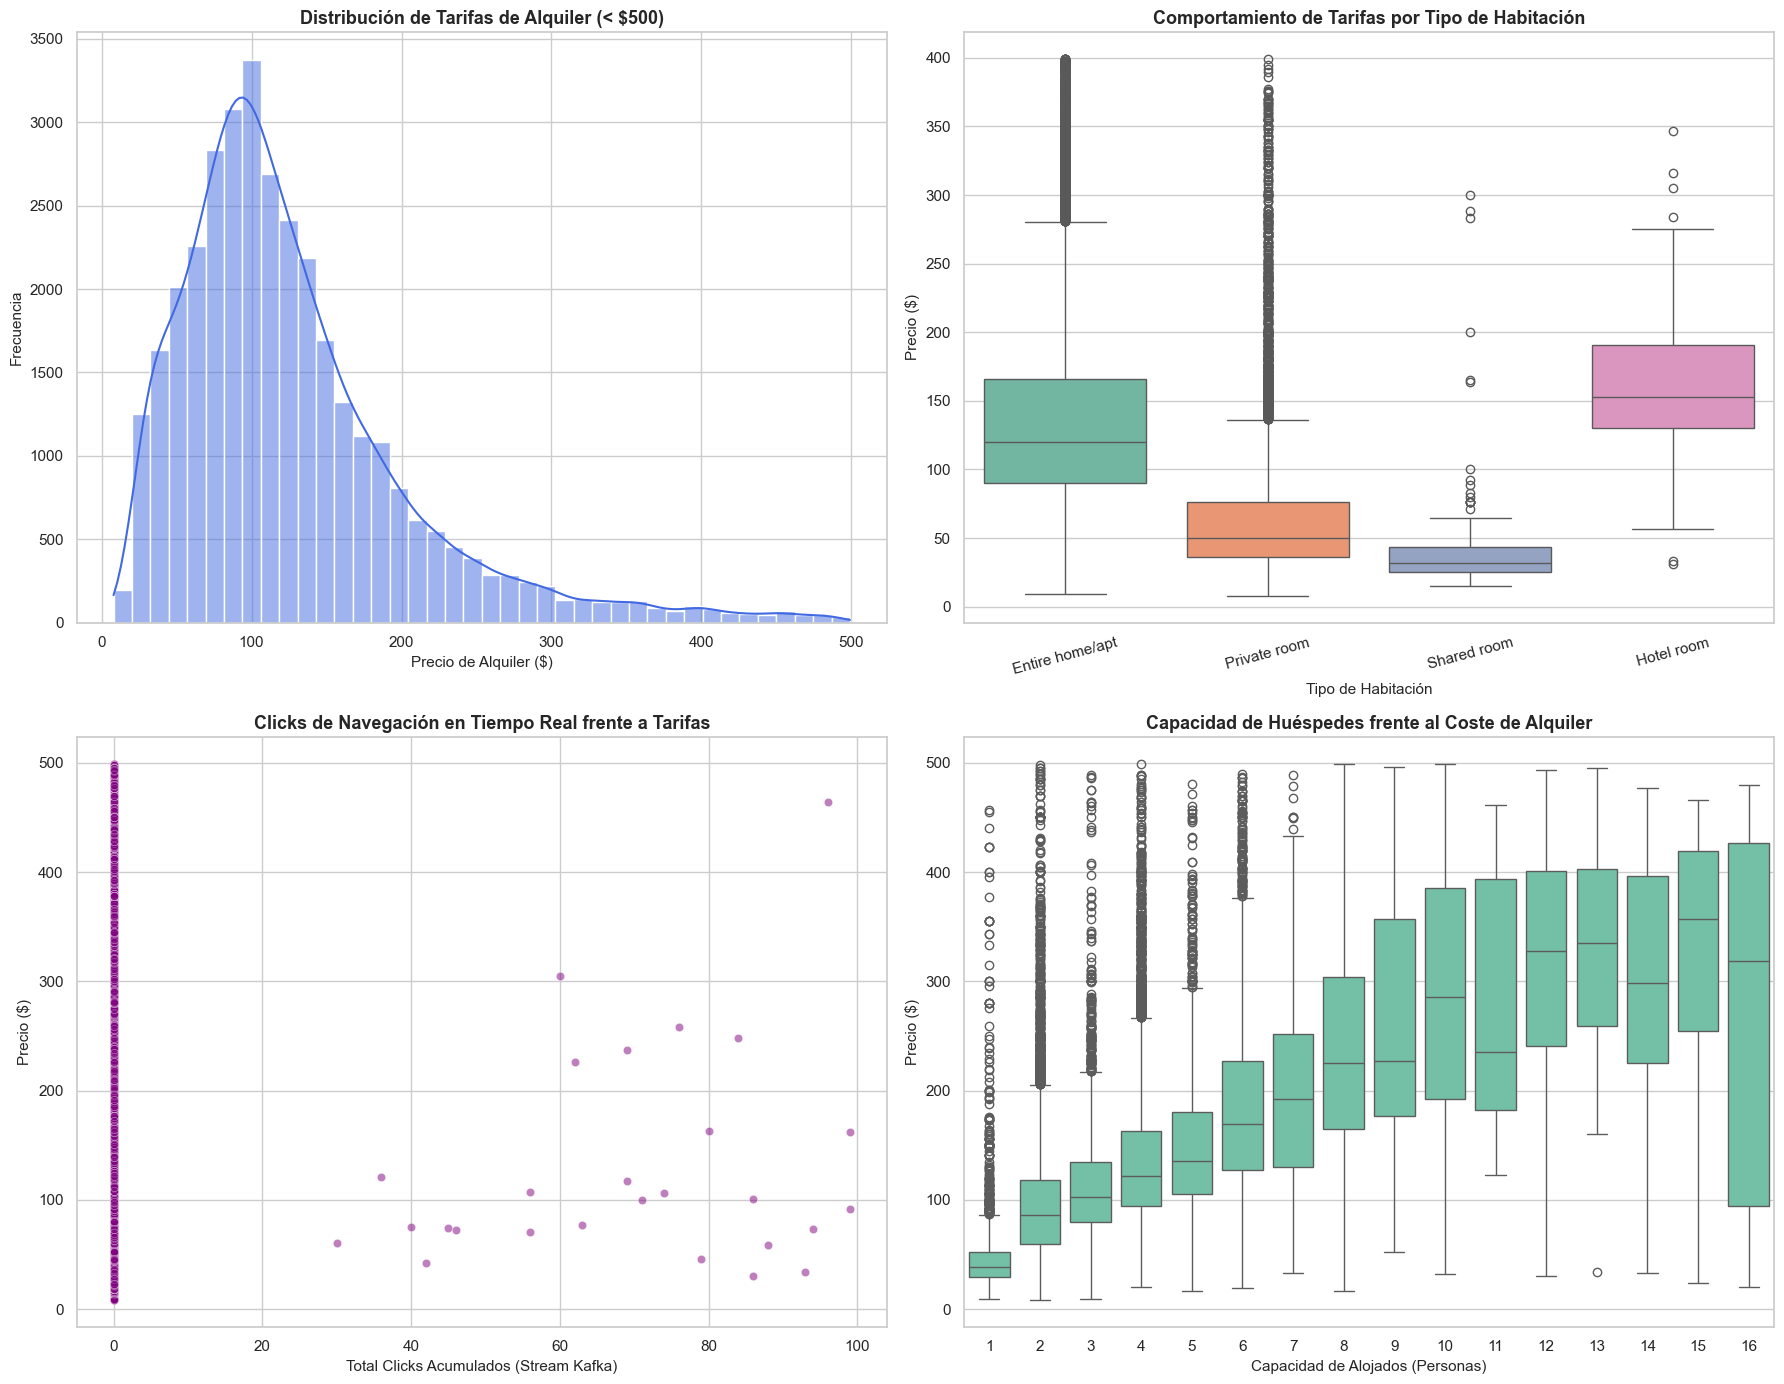

In [7]:
# Inicializar un lienzo de subplots de 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Histograma: Distribución de precios (filtramos < $500 para apreciar la curva sin la distorsión del lujo)
sns.histplot(df[df['price'] < 500]['price'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Distribución de Tarifas de Alquiler (< $500)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Precio de Alquiler ($)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)

# 2. Boxplot: Distribución de Precios según el Tipo de Habitación (Predictor categórico fuerte)
sns.boxplot(x='room_type', y='price', data=df[df['price'] < 400], ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Comportamiento de Tarifas por Tipo de Habitación', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Tipo de Habitación', fontsize=11)
axes[0, 1].set_ylabel('Precio ($)', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Scatterplot: Relación entre Clickstream en tiempo real (Kafka) y el Precio
sns.scatterplot(x='total_clicks_acumulados', y='price', data=df[df['price'] < 500], alpha=0.5, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Clicks de Navegación en Tiempo Real frente a Tarifas', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Total Clicks Acumulados (Stream Kafka)', fontsize=11)
axes[1, 0].set_ylabel('Precio ($)', fontsize=11)

# 4. Boxplot: Relación entre la Capacidad de Huéspedes (Alojados) y el Precio
sns.boxplot(x='accommodates', y='price', data=df[df['price'] < 500], ax=axes[1, 1], color='mediumaquamarine')
axes[1, 1].set_title('Capacidad de Huéspedes frente al Coste de Alquiler', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Capacidad de Alojados (Personas)', fontsize=11)
axes[1, 1].set_ylabel('Precio ($)', fontsize=11)

plt.tight_layout()
plt.show()

### 7. Análisis de Relación Lineal mediante Coeficiente de Pearson

Para cuantificar la colinealidad y el grado de influencia lineal que ejercen nuestras características independientes (predictores) sobre nuestra variable objetivo (`price`), calculamos la matriz de coeficientes de correlación de Pearson.

El coeficiente r de Pearson oscila en un rango de $[-1 \text{ a } 1]$, donde:
* $1$: Correlación positiva perfecta.
* $0$: Ausencia de relación lineal.
* $-1$: Correlación negativa perfecta.

Para una correcta interpretación académica, representaremos la matriz mediante un mapa de calor (Heatmap) provisto de una máscara triangular superior. Esto aísla las autocorrelaciones duplicadas y permite concentrar la atención visual en los predictores con mayor fuerza de asociación.

📉 MATRIZ DE CORRELACIÓN DE PEARSON - EVALUACIÓN MULTIMODELO:



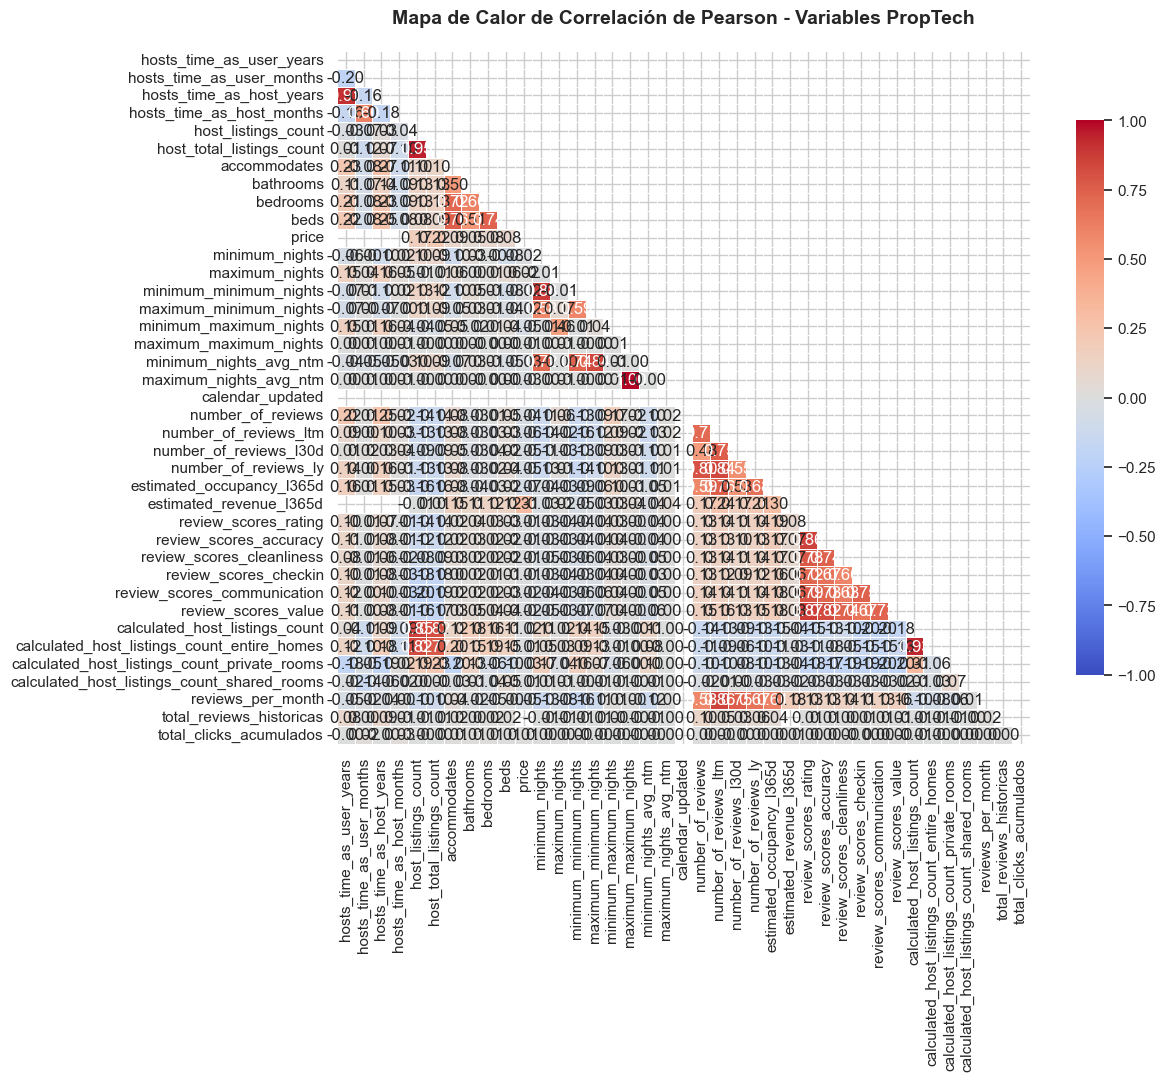

📌 Coeficientes de correlación directa respecto al Precio (Orden Descendente):
price                                           1.000000
estimated_revenue_l365d                         0.309875
host_total_listings_count                       0.215594
host_listings_count                             0.169829
accommodates                                    0.093687
bedrooms                                        0.082895
beds                                            0.081131
bathrooms                                       0.053188
maximum_nights                                  0.021463
total_clicks_acumulados                         0.011234
maximum_maximum_nights                         -0.005122
review_scores_cleanliness                      -0.008308
calculated_host_listings_count_entire_homes    -0.008915
calculated_host_listings_count_shared_rooms    -0.010402
review_scores_checkin                          -0.011324
review_scores_rating                           -0.013943
review_sco

In [10]:
print("📉 MATRIZ DE CORRELACIÓN DE PEARSON - EVALUACIÓN MULTIMODELO:\n")

# 1. Aislar las características numéricas, excluyendo coordenadas geográficas primarias
df_num = df.select_dtypes(include=[np.number]).drop(columns=['latitude', 'longitude'], errors='ignore')

# 2. Calcular los coeficientes de Pearson
matriz_corr = df_num.corr(method='pearson')

# 3. Generar una máscara booleana para ocultar la mitad superior simétrica
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# 4. Dibujar el mapa de calor adaptado para informes de TFM
plt.figure(figsize=(12, 9))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Mapa de Calor de Correlación de Pearson - Variables PropTech', fontsize=14, fontweight='bold', pad=20)
plt.show()

print("📌 Coeficientes de correlación directa respecto al Precio (Orden Descendente):")
print(matriz_corr['price'].sort_values(ascending=False))

📉 FILTRANDO MATRIZ DE CORRELACIÓN DE ALTA DIMENSIÓN...



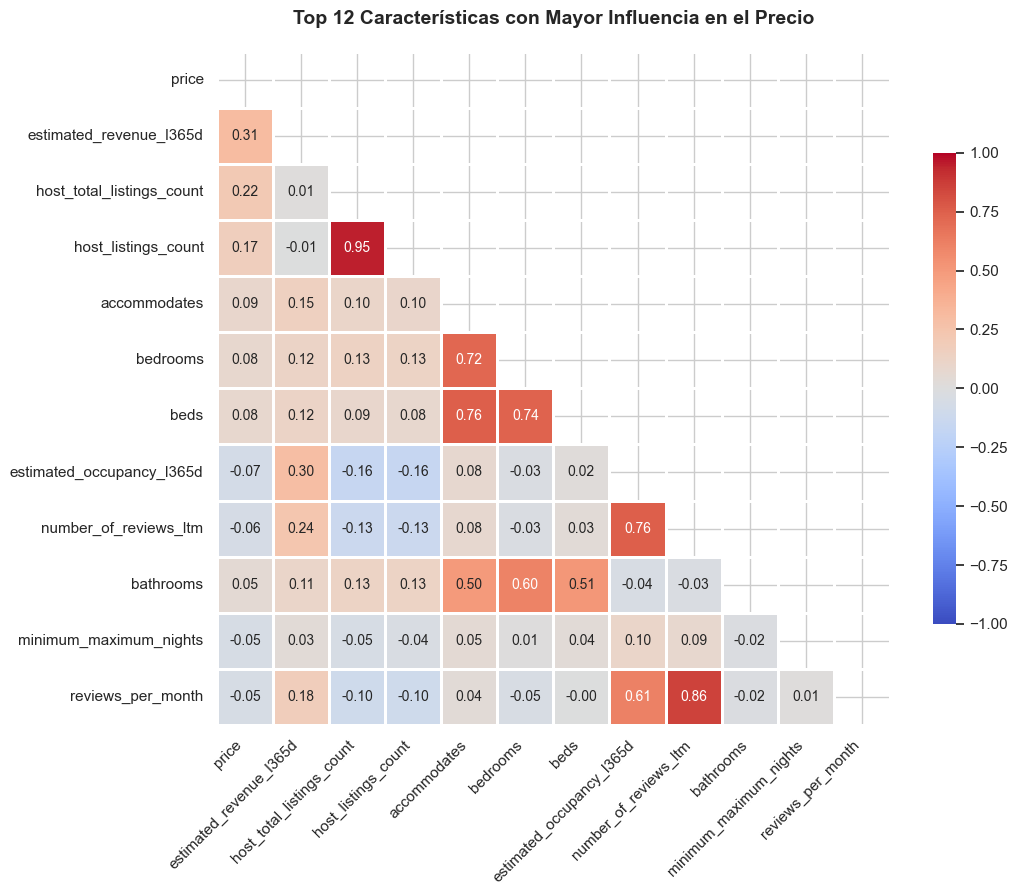

📌 Ranking completo de los 30+ predictores respecto al precio:


price                                           1.000000
estimated_revenue_l365d                         0.309875
host_total_listings_count                       0.215594
host_listings_count                             0.169829
accommodates                                    0.093687
bedrooms                                        0.082895
beds                                            0.081131
bathrooms                                       0.053188
maximum_nights                                  0.021463
total_clicks_acumulados                         0.011234
maximum_maximum_nights                         -0.005122
review_scores_cleanliness                      -0.008308
calculated_host_listings_count_entire_homes    -0.008915
calculated_host_listings_count_shared_rooms    -0.010402
review_scores_checkin                          -0.011324
review_scores_rating                           -0.013943
review_scores_accuracy                         -0.014082
calculated_host_listings_count 

In [11]:
print("📉 FILTRANDO MATRIZ DE CORRELACIÓN DE ALTA DIMENSIÓN...\n")

# 1. Seleccionar variables numéricas
df_num = df.select_dtypes(include=[np.number]).drop(columns=['latitude', 'longitude'], errors='ignore')

# 2. Calcular la matriz de correlación completa de Pearson
matriz_corr_completa = df_num.corr(method='pearson')

# 3. 🎯 EL TRUCO: Extraer las 12 variables con mayor correlación absoluta respecto al Precio
top_features = matriz_corr_completa['price'].abs().sort_values(ascending=False).head(12).index
matriz_corr_filtrada = matriz_corr_completa.loc[top_features, top_features]

# 4. Generar la máscara triangular para la matriz reducida
mask_filtrada = np.triu(np.ones_like(matriz_corr_filtrada, dtype=bool))

# 5. Dibujar el mapa de calor con espacio y tamaño de letra optimizado
plt.figure(figsize=(11, 9))

sns.heatmap(
    matriz_corr_filtrada, 
    annot=True,               # Mostrar los números
    fmt=".2f",                # Solo 2 decimales
    cmap="coolwarm",          # Escala de azul (negativo) a rojo (positivo)
    mask=mask_filtrada,       # Ocultar mitad duplicada
    vmin=-1, vmax=1,          # Límites de la escala
    square=True,              # Celdas perfectamente cuadradas
    linewidths=.8,            # Separación sutil entre celdas
    annot_kws={"size": 10},   # Tamaño de los números ideal para leer
    cbar_kws={"shrink": .7}   # Encoger la barra de color lateral para que cuadre
)

# Rotar las etiquetas para que no se pisen entre sí
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.title('Top 12 Características con Mayor Influencia en el Precio', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("📌 Ranking completo de los 30+ predictores respecto al precio:")
display(matriz_corr_completa['price'].sort_values(ascending=False))